In [182]:
import numpy as np
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve
import matplotlib.pyplot as plt


In [183]:
# CONSTANTS
mu = 0.012150582  # Stosunek masy Księżyca do masy układu Ziema-Księżyc
D_ZK = 1  # Ziemia - Księżyc odległość
M_ZK = 1  # Ziemia - Księżyc masa
V_ang = 1  # prędkość katowa układu ziemia księżyc

In [184]:
def place_equation(t, Y):
    global mu
    x,u,y,v = Y
    r1 =  np.sqrt((x+ mu)**2 + y**2)
    r2 =  np.sqrt((x-1+ mu)**2 + y**2)

    # DERIVATIVES
    xp =  u
    up =  x+2*v - ((1-mu)*(x+mu)/r1**3  +  mu*(x-1+mu)/r2**3)
    yp =  v
    vp =  y-2*u - ((1-mu)*y/r1**3  +  mu*y/r2**3)
    return np.array([xp,up,yp,vp])

In [185]:
# EARTH AND MOON POSITION
mass_centre = np.array([0,0])
Earth_centre = np.array([-mu,0])
Moon_centre = np.array([1-mu,0])

# ASTEROID POSITION AND VELOCITY
x,y = [1.05,0.1]
u,v = [-0.45,-0.25]
start_state = np.array([x,u,y,v])


N = 100
t0 = 0
tk = 5


In [186]:
def print_plot(axes,x_s,y_s,method_name,t_s):
    L1 = [1 - (mu/3)**(1/3),0]
    L2 = [1 + (mu/3)**(1/3),0]
    L3 = [-(1 + (5*mu/12)),0]
    L4 = [0.5 - mu,np.sqrt(3)/2]
    L5 = [0.5 - mu,-np.sqrt(3)/2]

    x_l = [L1[0],L2[0],L3[0],L4[0],L5[0]]
    y_l = [L1[1],L2[1],L3[1],L4[1],L5[1]]

    global Earth_centre,Moon_centre

    axes[0].set_title(f"metoda {method_name} trajektoria (x,y)")
    axes[0].axis('equal')

    axes[0].plot(x_s,y_s)
    axes[0].scatter([Earth_centre[0]],Earth_centre[1],color="green")
    axes[0].scatter(Moon_centre[0],Moon_centre[1],color="grey")
    axes[0].scatter(x_l,y_l,color="orange")


    axes[1].set_title(f"metoda {method_name} x(t)")
    axes[1].plot(t_s,x_s)

    axes[2].set_title(f"metoda {method_name} y(t)")
    axes[2].plot(t_s,y_s)



In [187]:
def inertial_system(axes,x_ast,y_ast,x_earth,y_earth,x_moon,y_moon,method_name):
    axes[3].set_title(f"metoda {method_name} ruch w układzie inercjalnym")
    axes[3].plot(x_ast,y_ast,color='red')
    axes[3].plot(x_earth,y_earth,color='green')
    axes[3].plot(x_moon,y_moon,color='grey')

In [188]:
def euler(h,start,beg,end):
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        result.append(y_k)
        displacement = place_equation(0,y_k)
        y_k1 = y_k+ h*displacement
        y_k = y_k1
    result.append(y_k)
    return result

In [189]:
def euler_implicit(h,start,beg,end):
    # 0 = -y_k1 +y_k +h_k * f(t_k1,y_k1)
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        def error(Y_k1):
            derivs = place_equation(0, Y_k1)
            err = Y_k1 - y_k - h * derivs
            return err
        result.append(y_k)
        y_k1 = fsolve(error,y_k)
        y_k = y_k1
    result.append(y_k)
    return result

In [190]:
def euler_semi_implicit(h,start,beg,end):
    n = int((end-beg)/h +1)
    y_k = np.array(start)
    result = []
    for i in range(n):
        result.append(y_k)

        def error(Y_k1):
            nonlocal y_k
            x_k1,u_k1,y_k1,v_k1 = Y_k1
            x_k0,u_k0,y_k0,v_k0 = y_k
            derivs = place_equation(0, np.array([x_k0,u_k1,y_k0,v_k1]))
            err = Y_k1 - y_k - h * derivs
            return err

        y_k = fsolve(error,y_k)
    result.append(y_k)
    return result


In [191]:
def runge_kutta45(h,start,beg,end):
    n = int((tk-t0)/h +1)
    t_s = np.linspace(t0,tk,n+1)
    return solve_ivp(place_equation,[beg,end],start,t_eval=t_s).y.T

In [192]:
def runge_kutta(h,start,beg,end):
    n = int((end - beg) / h + 1)
    y_k = np.array(start)
    result = []

    for i in range(n):
        result.append(y_k)

        k1 = np.array(place_equation(0, y_k))
        k2 = np.array(place_equation(0, y_k + (h / 2) * k1))
        k3 = np.array(place_equation(0, y_k + (h / 2) * k2))
        k4 = np.array(place_equation(0, y_k + h * k3))


        y_k1 = y_k + (h / 6) * (k1 + 2*k2 + 2*k3 + k4)

        y_k = y_k1

    result.append(y_k)
    return result

In [193]:
h = 1e-5

In [194]:
def calculate_inertial_velocity(t_s, x_s, u_s, y_s, v_s):
    U_ast = (
        u_s * np.cos(t_s) - v_s * np.sin(t_s) + x_s * np.sin(t_s) + y_s * np.cos(t_s)
    )
    V_ast = (
        u_s * np.sin(t_s) + v_s * np.cos(t_s) - x_s * np.cos(t_s) + y_s * np.sin(t_s)
    )
    return U_ast, V_ast


def calculate_energies(x_s, u_s, y_s, v_s):
    r1 = np.sqrt((x_s + mu) ** 2 + y_s**2)
    r2 = np.sqrt((x_s - 1 + mu) ** 2 + y_s**2)

    T = 0.5 * (u_s**2 + v_s**2)
    U_pot = 0.5 * (x_s**2 + y_s**2) + (1 - mu) / r1 + mu / r2
    return T, U_pot


def calculate_jacobi(x_s, u_s, y_s, v_s):
    r1 = np.sqrt((x_s + mu) ** 2 + y_s**2)
    r2 = np.sqrt((x_s - 1 + mu) ** 2 + y_s**2)

    C = x_s**2 + y_s**2 + 2 * (1 - mu) / r1 + 2 * mu / r2 - u_s**2 - v_s**2
    return C


euler


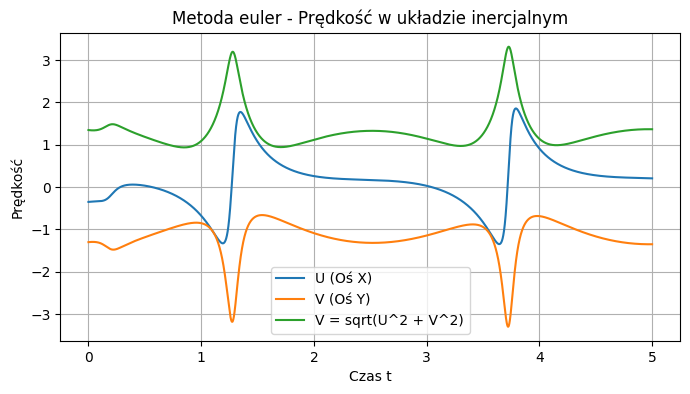

euler_implicit


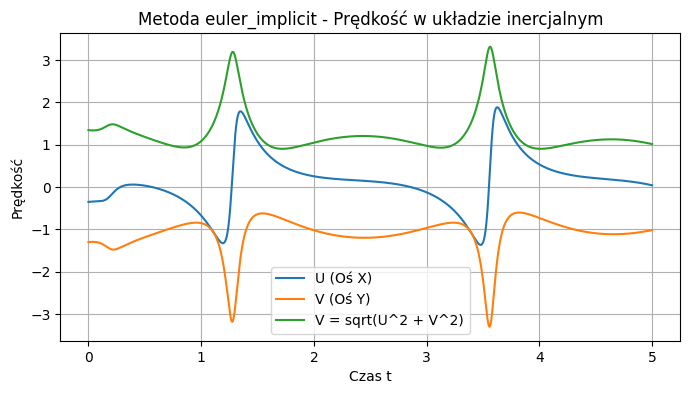

euler_semi_implicit


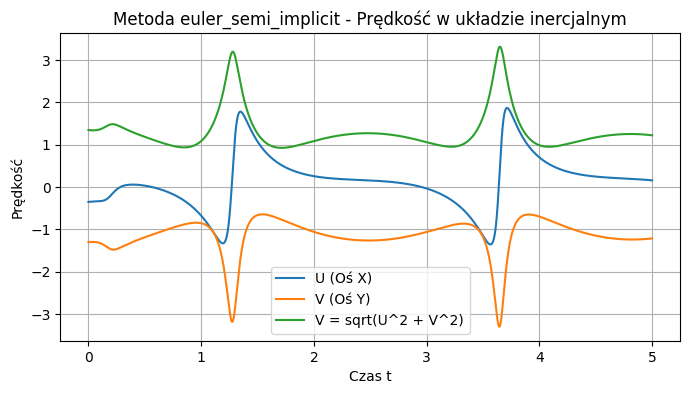

runge_kutta


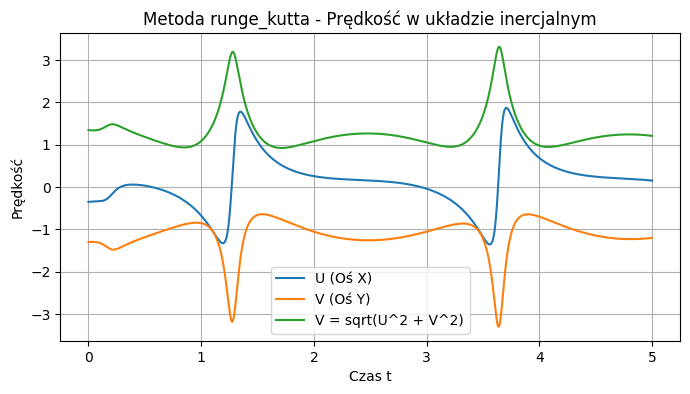

In [195]:
h = 1e-4
n = int((tk - t0) / h + 1)
t_s = np.linspace(t0, tk, n + 1)

results_dict = {}
methods = [euler, euler_implicit, euler_semi_implicit, runge_kutta]

for method in methods:
    print(f"{method.__name__}")

    res = np.array(method(h, start_state, t0, tk))
    results_dict[method.__name__] = res

    x_s, u_s, y_s, v_s = res[:, 0], res[:, 1], res[:, 2], res[:, 3]


    # (e)
    U_ast, V_ast = calculate_inertial_velocity(t_s, x_s, u_s, y_s, v_s)
    V_pom = np.sqrt(U_ast**2 + V_ast**2)

    plt.figure(figsize=(8, 4))
    plt.plot(t_s, U_ast, label="U (Oś X)")
    plt.plot(t_s, V_ast, label="V (Oś Y)")
    plt.plot(t_s, V_pom, label="V = sqrt(U^2 + V^2)")
    plt.title(f"Metoda {method.__name__} - Prędkość w układzie inercjalnym")
    plt.xlabel("Czas t")
    plt.ylabel("Prędkość")
    plt.legend()
    plt.grid(True)
    plt.show()


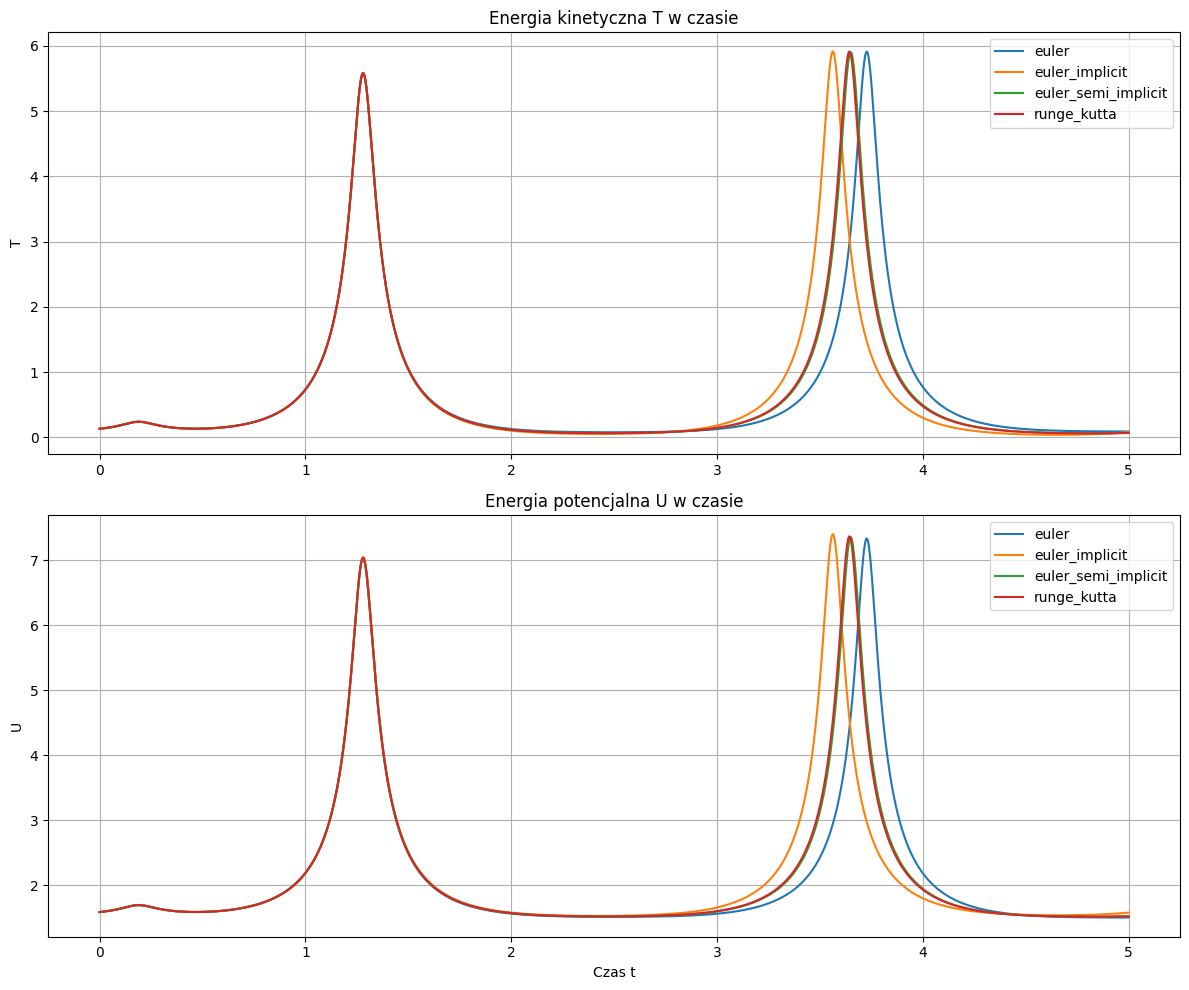

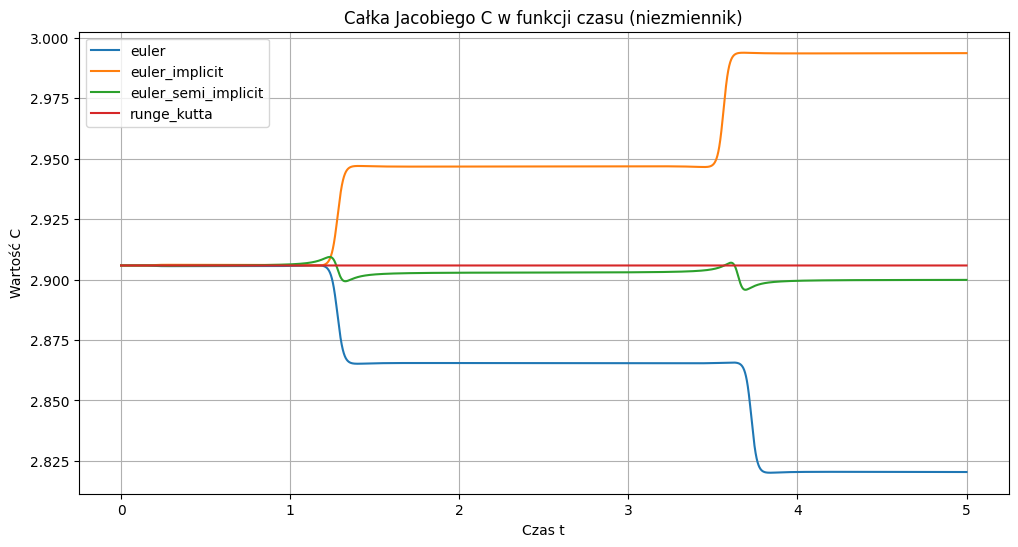

In [196]:
# (f)

fig, (ax_T, ax_U) = plt.subplots(2, 1, figsize=(12, 10))

for method_name, res in results_dict.items():
    x_s, u_s, y_s, v_s = res[:, 0], res[:, 1], res[:, 2], res[:, 3]
    T, U_pot = calculate_energies(x_s, u_s, y_s, v_s)

    ax_T.plot(t_s, T, label=method_name)
    ax_U.plot(t_s, U_pot, label=method_name)

ax_T.set_title("Energia kinetyczna T w czasie")
ax_T.set_ylabel("T")
ax_T.legend()
ax_T.grid(True)

ax_U.set_title("Energia potencjalna U w czasie")
ax_U.set_xlabel("Czas t")
ax_U.set_ylabel("U")
ax_U.legend()
ax_U.grid(True)

plt.tight_layout()
plt.show()

# (g)

plt.figure(figsize=(12, 6))

for method_name, res in results_dict.items():
    x_s, u_s, y_s, v_s = res[:, 0], res[:, 1], res[:, 2], res[:, 3]
    C = calculate_jacobi(x_s, u_s, y_s, v_s)

    plt.plot(t_s, C, label=method_name)

plt.title("Całka Jacobiego C w funkcji czasu (niezmiennik)")
plt.xlabel("Czas t")
plt.ylabel("Wartość C")
plt.legend()
plt.grid(True)
plt.show()


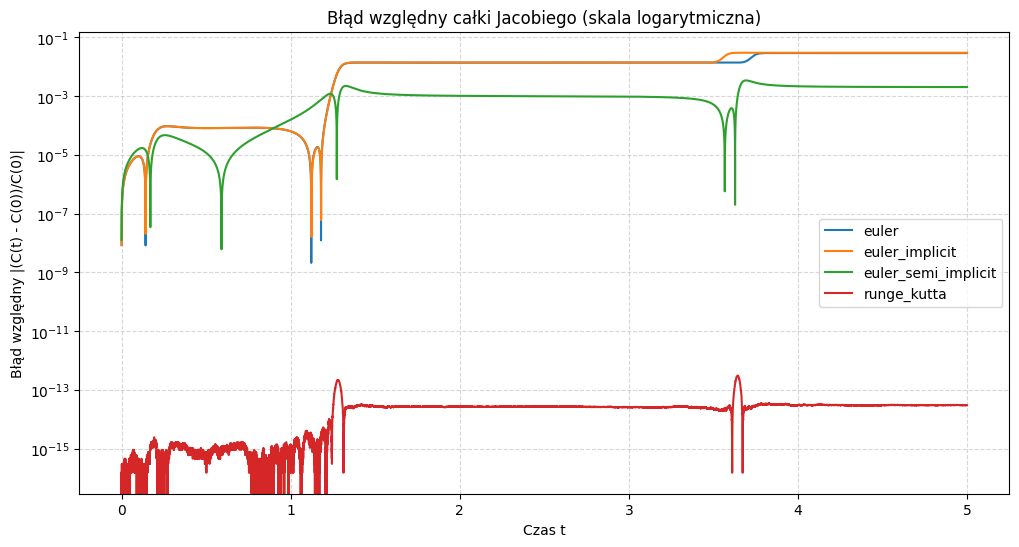

In [197]:
plt.figure(figsize=(12, 6))

for method_name, res in results_dict.items():
    x_s, u_s, y_s, v_s = res[:, 0], res[:, 1], res[:, 2], res[:, 3]

    C = calculate_jacobi(x_s, u_s, y_s, v_s)

    C_0 = C[0]
    rel_error = np.abs((C - C_0) / C_0)

    rel_error[0] = np.nan

    plt.plot(t_s, rel_error, label=method_name)

plt.title("Błąd względny całki Jacobiego (skala logarytmiczna)")
plt.xlabel("Czas t")
plt.ylabel("Błąd względny |(C(t) - C(0))/C(0)|")
plt.yscale("log")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.show()
